# Student Employability Analysis and Placement Prediction


## 1. Objective
The goal of this project is to analyze student data and identify factors that influence placement outcomes. Later, a machine learning model will be developed to predict whether a student is likely to be placed. 

In [2]:
#Imprting libraries
import pandas as pd
import numpy as np
import seaborn as sns

## 2. Loading the Dataset

In [3]:
df = pd.read_csv("placementdata.csv")
df.head()


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


## 3. Dataset Overview 
The dataset contains academic, skilled-based, and extracurricular information about students along with their placement status.

In [4]:
df.shape

(10000, 12)

In [5]:
df.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  str    
 8   PlacementTraining          10000 non-null  str    
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  str    
dtypes: float64(2), int64(7), str(3)
memory usage: 937.6 KB


In [7]:
df.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


## 4. Data Quality Assessment

In [8]:
df.isnull().sum()

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

#### Dataset Overview
The Dataset contains 10,000 student records and 12 columns.<br>
There are no missing values were found.<br>
The target column is Placement_Status, which indicates whether a student was placed or not placed. <br>
The dataset contains academic, skill-based, and training-related attributes such as CGPA, internships, projects, aptitude scores, and soft skills ratings. Most features are numerical.<br>

## 5. Target Variable Analysis
### Placement Status Distribution

In [10]:
df["PlacementStatus"].value_counts()

PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

#### Observation 
The dataset contains 10,000 student records.<br>
- 5,803 students were not placed.<br>
- 4,197 students were placed.<br>
The target value is moderately inbalanced, with approximately 58% of students not placed and 42% placed. However, the imbalance is not severe enough to prevent building machine learning model.


In [11]:
df["PlacementStatus"].value_counts(normalize=True)*100

PlacementStatus
NotPlaced    58.03
Placed       41.97
Name: proportion, dtype: float64

 
Visualizing the number of placed and non-placed students.

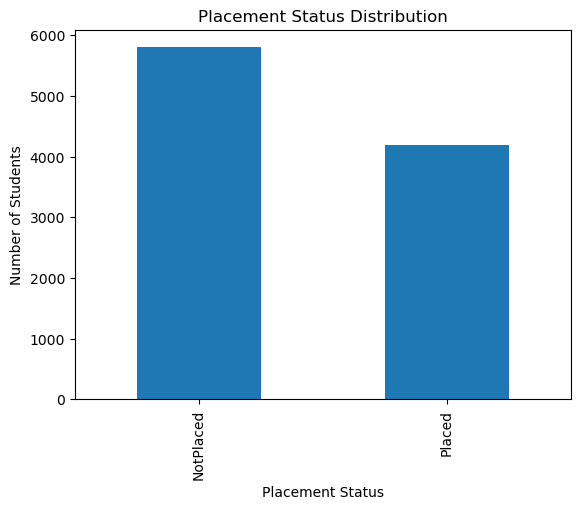

In [12]:
import matplotlib.pyplot as plt
df["PlacementStatus"].value_counts().plot(kind="bar")
plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

## 6. Feature-wise Analysis
### 6.1 CGPA Analysis
Analyzing the relationship between CGPA and placement status.

In [13]:
df.groupby("PlacementStatus")["CGPA"].mean()

PlacementStatus
NotPlaced    7.467672
Placed       8.016488
Name: CGPA, dtype: float64

#### Observation 
Students who were placed have a higher average CGPA (8.02) compared to students who were not placed (7.47). <br>
This suggests that academic performance may have a positive influence on placement outcomes.

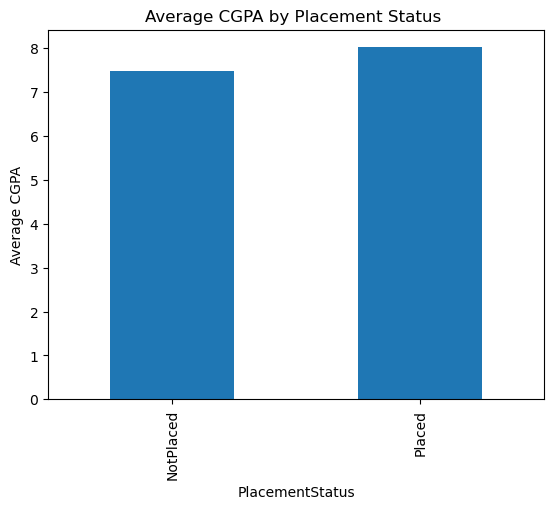

In [14]:
df.groupby("PlacementStatus")["CGPA"].mean().plot(kind="bar")
plt.title("Average CGPA by Placement Status ")
plt.ylabel("Average CGPA")
plt.show()

### 6.2 Internship Analysis

In [15]:
df.groupby("PlacementStatus")["Internships"].mean()

PlacementStatus
NotPlaced    0.901775
Placed       1.253038
Name: Internships, dtype: float64

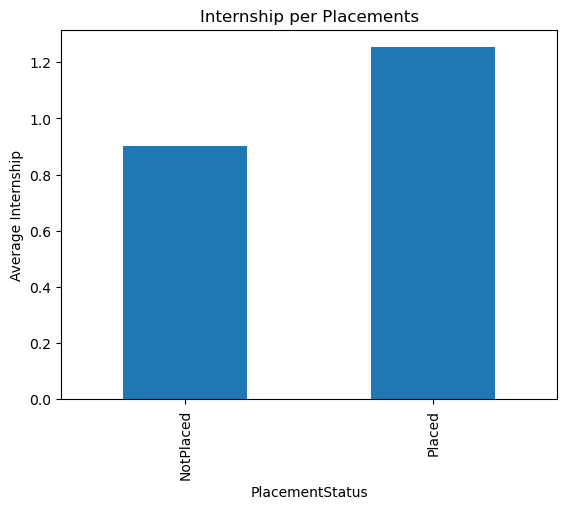

In [16]:
df.groupby("PlacementStatus")["Internships"].mean().plot(kind="bar")
plt.title("Internship per Placements")
plt.ylabel("Average Internship")
plt.show()

## 7. Univariate Analysis
Univariate analysis focuses on examining one variable at a time to understand its distribution, spread, central tendency, and presence of outliers. This step helps identify unusual patterns and provides insights into the characteristics of individual features before studying relationships between multiple variables.

- Understand the distribution of each feature.
- Detect skewness in the data.
- Identify potential outliers.
- Understand the variability of numerical features.
- Prepare the dataset for machine learning.

### 7.1 Distribution of CGPA 
CGPA is one of the most influential academic indicators in student placement prediction. Analyzing its distribution helps us understand the academic performance of students and identify whether the values are normally distributed, skewed, or contain any unusual observations.

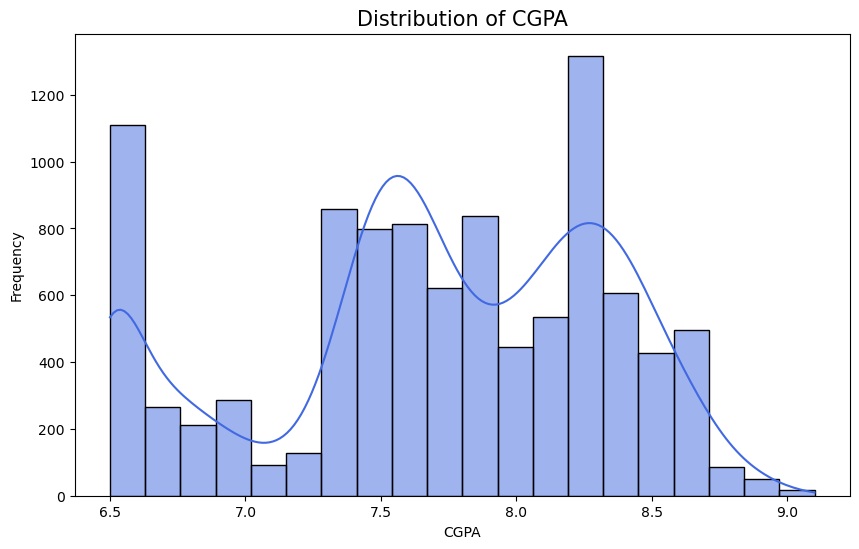

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='CGPA',
    kde="True",
    bins=20,
    color='royalblue'
)
plt.title("Distribution of CGPA", fontsize=15)
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

#### Observation

- The CGPA values range approximately from 6.5 to 9.1, indicating realistic academic scores.
- Most students have CGPA values between 7.4 and 8.5, suggesting that the majority of students have good academic performance.
- The distribution is not perfectly normal and appears to have multiple regions where values are concentrated.
- Overall, the CGPA feature appears to be well-distributed and suitable for further exploratory analysis and machine learning.
  

### 7.2 Outlier Detection of CGPA 
After understanding the distribution of CGPA, it is important to identify whether the dataset contains any outliers. Outliers are observations that differ significantly from the majority of the data and may affect statistical analysis and machine learning models.
A box plot provides a simple visual representation of the spread of data and helps identify potential outliers using the Interquartile Range (IQR) method [IQR=Q3-Q1].

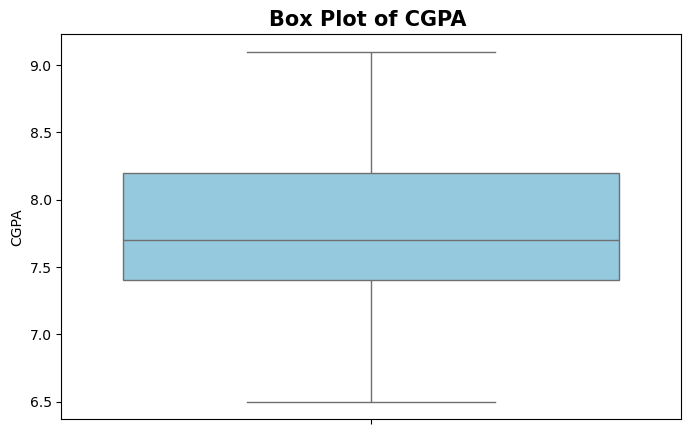

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    y=df['CGPA'],
    color='skyblue'
    )
plt.title("Box Plot of CGPA ", fontsize=15, fontweight='bold')
plt.ylabel("CGPA")
plt.show()

### 7.3 Aptitude Test Score Analysis
The aptitude test score measures a student's problem-solving and analytical abilities. Analyzing its distribution helps identify score patterns, detect outliers, and understand whether aptitude is likely to influence placement outcomes.


#### Histogram

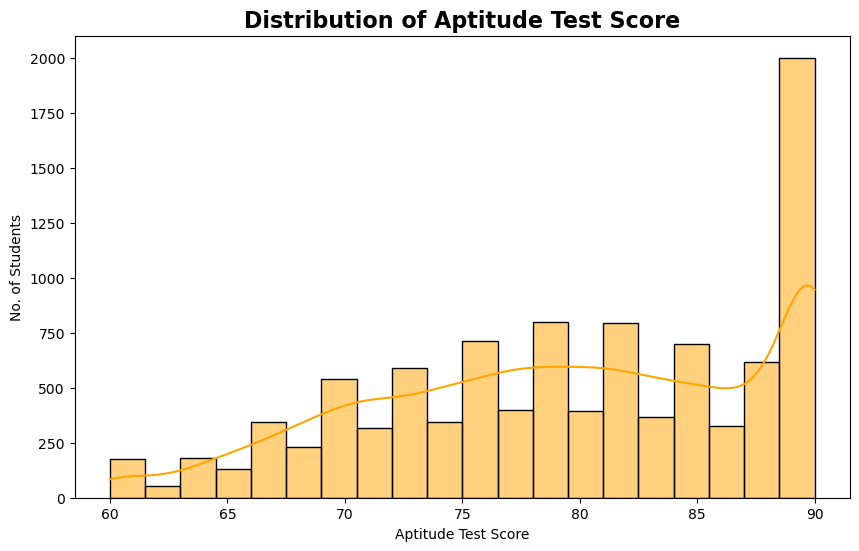

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='AptitudeTestScore',
    kde=True,
    bins=20,
    color="orange"
)
plt.title("Distribution of Aptitude Test Score", fontsize=16, fontweight='bold')
plt.xlabel("Aptitude Test Score")
plt.ylabel("No. of Students")

plt.show()

####  Box plot

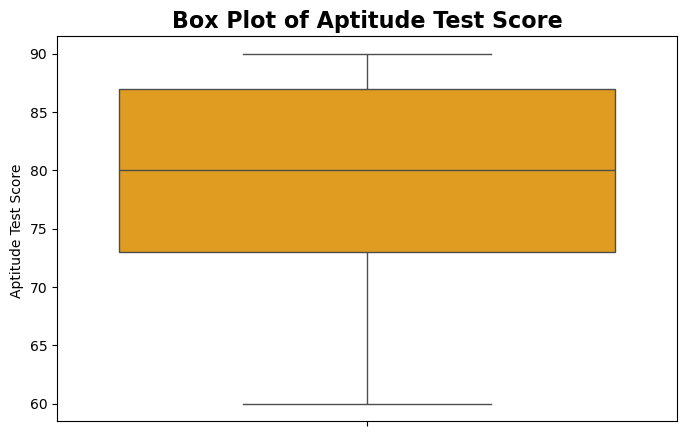

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(
    y=df["AptitudeTestScore"],
    color='orange'
)
plt.title("Box Plot of Aptitude Test Score", fontsize=16, fontweight='bold')
plt.ylabel("Aptitude Test Score ")

plt.show()

### 7.4 Soft Skills Rating Analysis
Soft skills such as communication, teamwork, and leadership often influence placement distribution and spread of soft skill ratings among students

#### Histogram

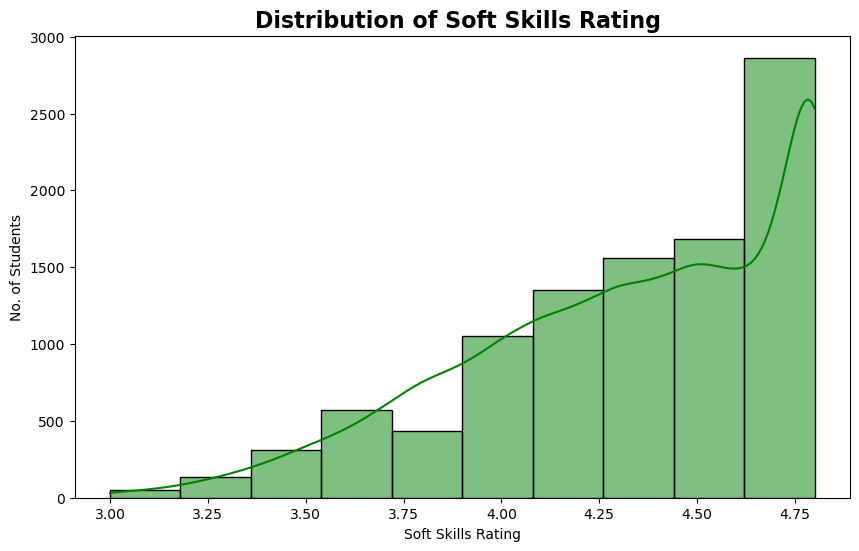

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x=df["SoftSkillsRating"],
    kde='True',
    bins=10,
    color='green'
)
plt.title("Distribution of Soft Skills Rating ", fontsize=16 , fontweight='bold')
plt.xlabel("Soft Skills Rating")
plt.ylabel("No. of Students")
plt.show()

#### Box plot

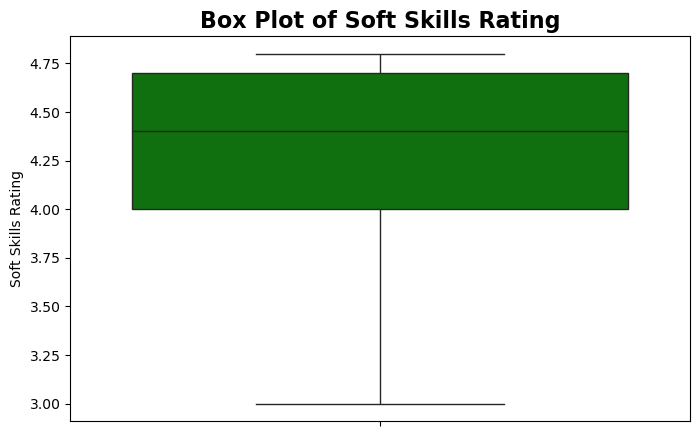

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(
    y=df["SoftSkillsRating"],
    color='green'
)
plt.title("Box Plot of Soft Skills Rating", fontsize=16, fontweight='bold')
plt.ylabel("Soft Skills Rating")
plt.show()

##### Observation 

- The Soft Skills Rating ranges approximately from **3.0 to 4.8**, indicating that students generally possess moderate to high soft skill ratings.
- Most students have ratings between **4.0 and 4.8**, suggesting that a large proportion of students demonstrate strong communication and interpersonal skills.
- The histogram shows a slight negative (left) skew, indicating that higher soft skill ratings are more common than lower ratings.
- The box plot does not display any significant outliers, suggesting that the data is consistent and free from extreme observations.
- The median soft skills rating is around **4.4**, indicating that at least half of the students have relatively high soft skill ratings.

##### Conclusion
The Soft Skills Rating feature is well distributed and does not contain significant outliers. Therefore, it is suitable for further analysis and machine learning without requiring outlier treatment.

### 7.5 Remaining Features
The remaining numerical features exhibit reasonable distributions without obvious anomalies.These features will be evaluated during correlation analysis and model training to determine their contribution to placement prediction.

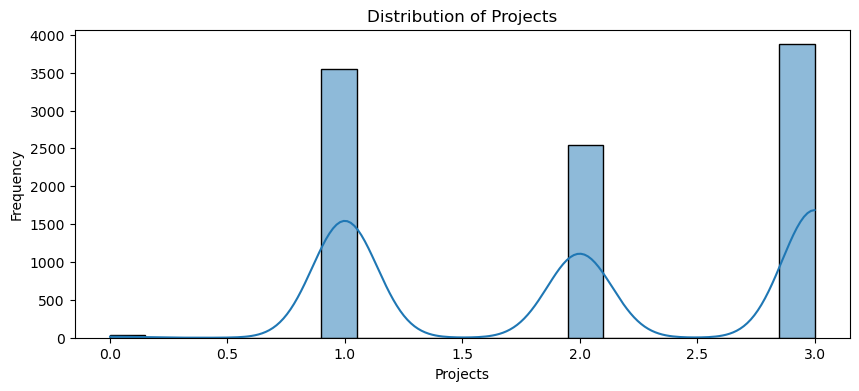

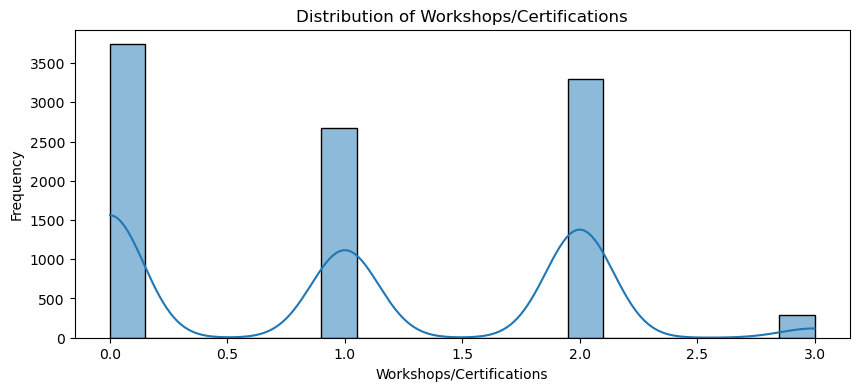

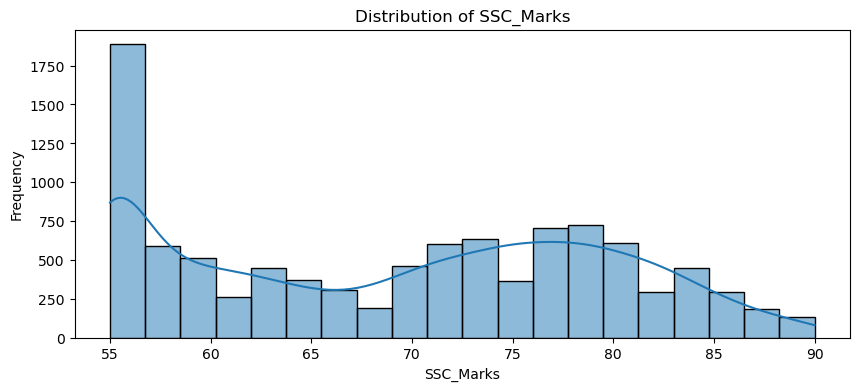

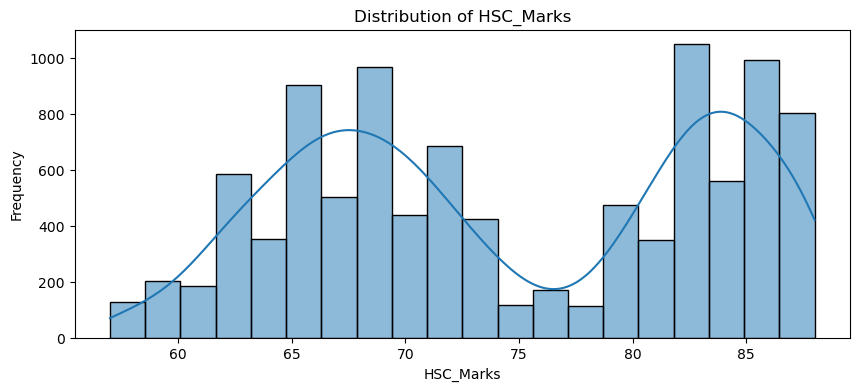

In [35]:
features=[
    'Projects',
    'Workshops/Certifications',
    'SSC_Marks',
    'HSC_Marks'
]

for feature in features:
    plt.figure(figsize=(10,4))

    sns.histplot(df[feature],kde=True,bins=20)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

##### Observation

- The remaining numerical features, namely **Projects, Workshops/Certifications, SSC Marks, and HSC Marks**, exhibit reasonable distributions with no obvious anomalies.
- The Projects feature is concentrated around discrete values, reflecting the limited number of projects completed by students.
- Workshops/Certifications also display discrete distributions, indicating varying levels of participation among students.
- SSC Marks and HSC Marks show a wider spread of academic performance across students without any unrealistic values.
- Overall, these features appear suitable for further analysis and machine learning model development.

##### Conclusion

The remaining numerical features exhibit meaningful variability and do not show any obvious data quality concerns. Their predictive importance will be further evaluated during correlation analysis and machine learning model training.

## 8. Correlation Analysis 
Correlation analysis measures the strength and direction of relationships between numerical variables. It helps identify highly related features and detect muticollinearity before model training.

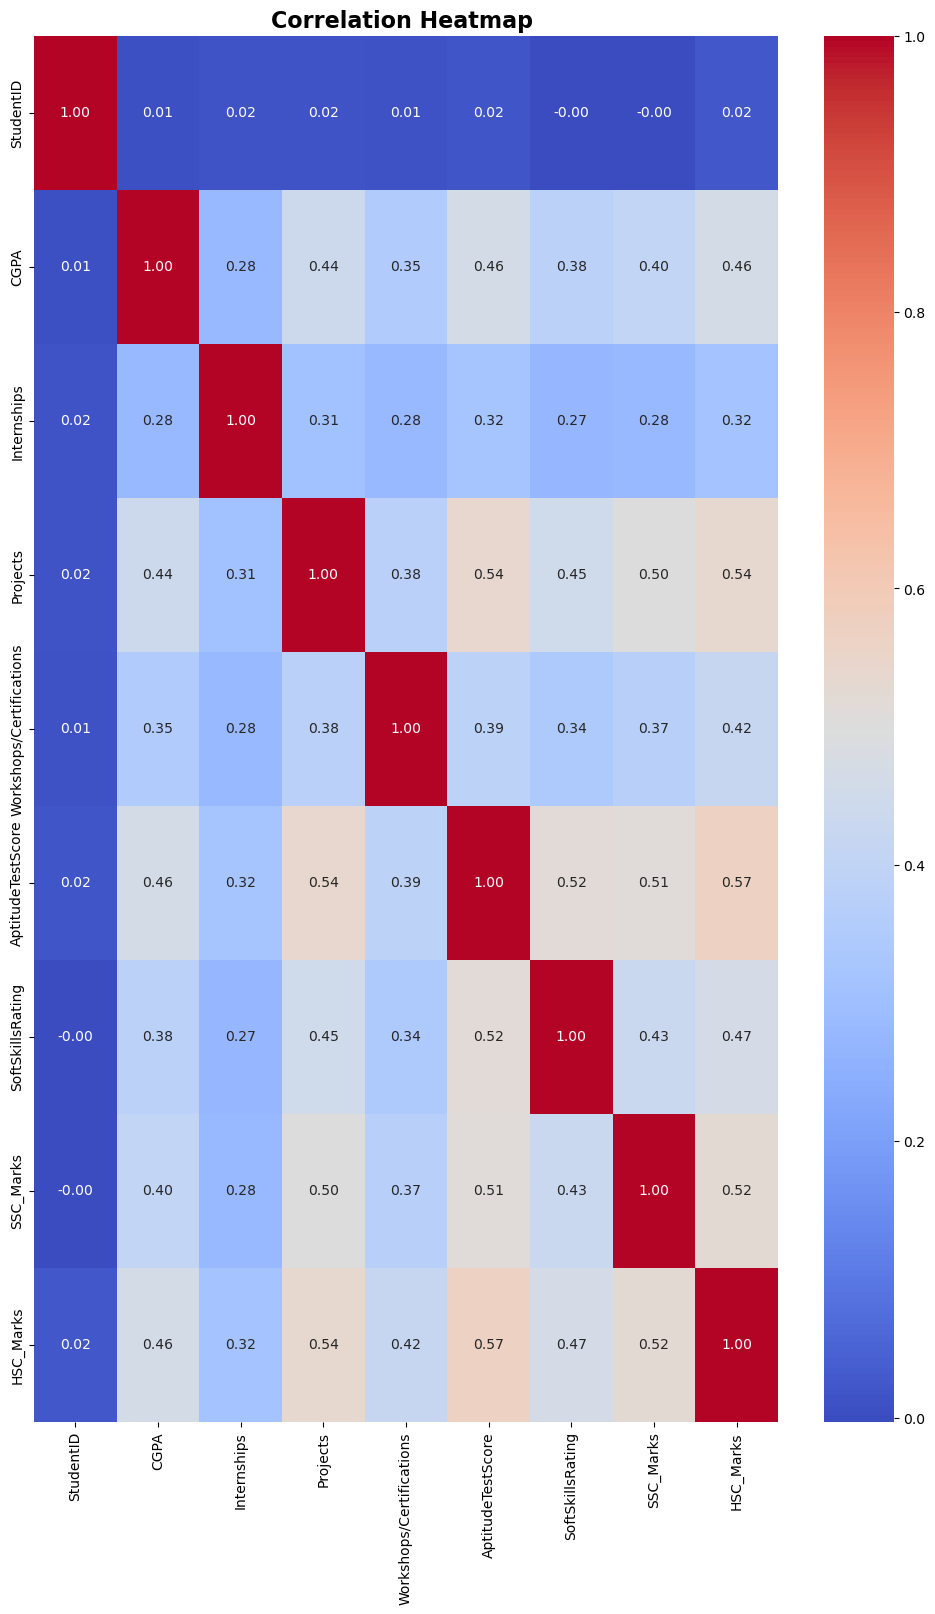

In [46]:
numerical_df=df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(12,18))
sns.heatmap(
numerical_df.corr(),
cmap='coolwarm',
annot=True,
fmt=".2f",
)
plt.title("Correlation Heatmap ",fontsize=16, fontweight='bold')



plt.show()

##### Observation

- The correlation heatmap illustrates the strength and direction of relationships between the numerical features in the dataset.
- Most feature pairs exhibit **weak to moderate positive correlations**, indicating that while they are related, they do not provide identical information.
- The highest positive correlation is observed between **HSC Marks** and **Workshops/Certifications** (approximately **0.57**), suggesting that students with better academic performance in higher secondary education tend to participate more in workshops and certifications.
- **Projects** also show moderate positive correlations with **Workshops/Certifications (0.54)** and **HSC Marks (0.54)**, indicating that academically active students are also more engaged in practical learning activities.
- **Soft Skills Rating** has a moderate positive correlation with **Workshops/Certifications (0.52)**, suggesting that students participating in workshops may also develop stronger interpersonal and communication skills.
- No feature pair exhibits a correlation coefficient greater than **0.8**, indicating the absence of severe multicollinearity among the numerical variables.

##### Conclusion

The numerical features exhibit meaningful but not excessive correlations. Therefore, no feature needs to be removed due to multicollinearity at this stage, and all numerical variables can be considered for machine learning model development.